In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.head()

print(df.shape)
df.info()
print(df.isnull().sum())


(360, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Order_Batch_ID           360 non-null    object        
 1   Date                     360 non-null    datetime64[ns]
 2   Month                    360 non-null    object        
 3   Day                      360 non-null    object        
 4   City                     360 non-null    object        
 5   Cuisine                  360 non-null    object        
 6   Order_Channel            360 non-null    object        
 7   Weather                  360 non-null    object        
 8   Orders                   360 non-null    int64         
 9   Average_Order_Value      360 non-null    float64       
 10  Revenue                  360 non-null    float64       
 11  Marketing_Spend          360 non-null    float64       
 12  Discounts                3

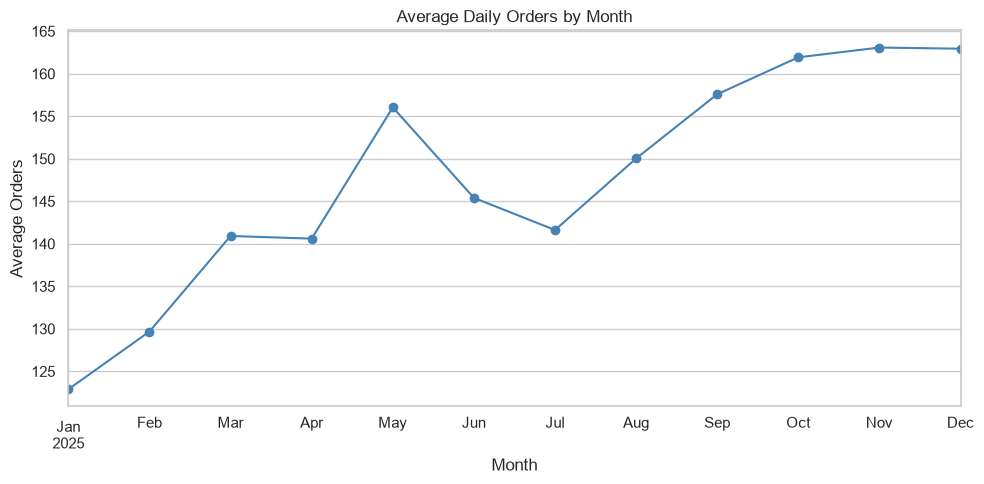

In [16]:
monthly_orders = df.groupby(df['Date'].dt.to_period('M'))['Orders'].mean()

plt.figure(figsize=(10,5))
monthly_orders.plot(kind='line', marker='o', color='steelblue')
plt.title('Average Daily Orders by Month')
plt.xlabel('Month')
plt.ylabel('Average Orders')
plt.tight_layout()
plt.show()

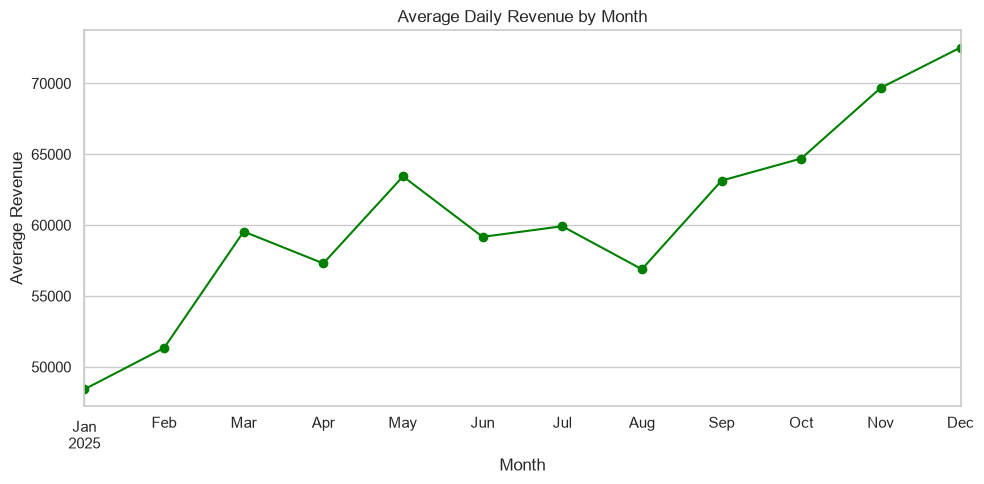

In [17]:
monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Revenue'].mean()

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind='line', marker='o', color='green')
plt.title('Average Daily Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.tight_layout()
plt.show()

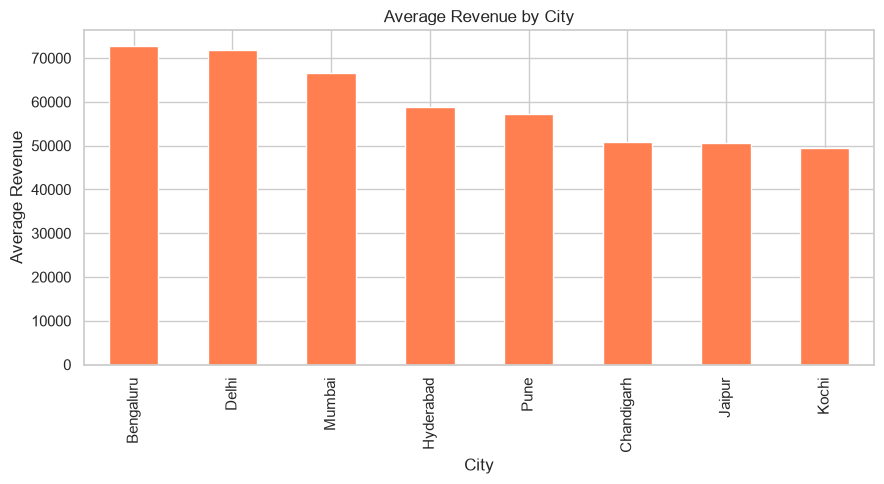

In [18]:
city_revenue = df.groupby('City')['Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
city_revenue.plot(kind='bar', color='coral')
plt.title('Average Revenue by City')
plt.xlabel('City')
plt.ylabel('Average Revenue')
plt.tight_layout()
plt.show()

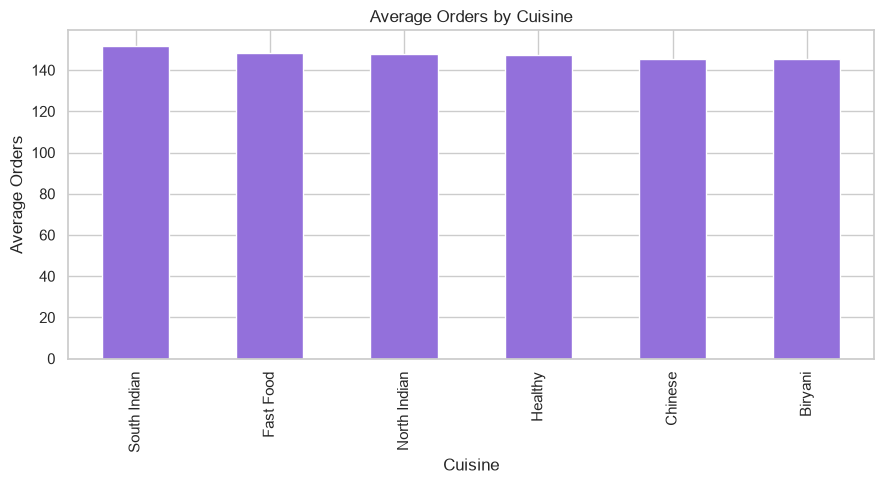

In [19]:
cuisine_orders = df.groupby('Cuisine')['Orders'].mean().sort_values(ascending=False)

plt.figure(figsize=(9,5))
cuisine_orders.plot(kind='bar', color='mediumpurple')
plt.title('Average Orders by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Orders')
plt.tight_layout()
plt.show()

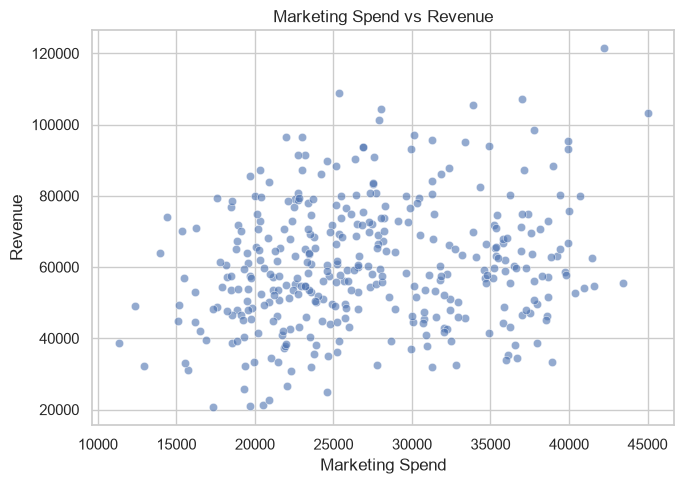

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Marketing_Spend', y='Revenue', data=df, alpha=0.6)
plt.title('Marketing Spend vs Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

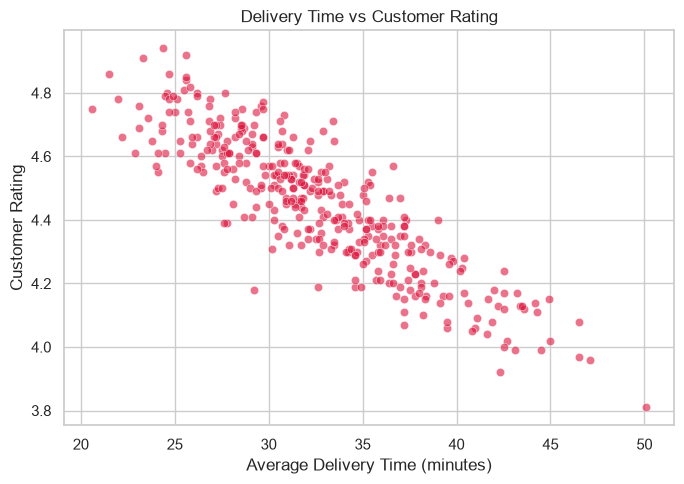

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Avg_Delivery_Minutes', y='Customer_Rating', data=df, alpha=0.6, color='crimson')
plt.title('Delivery Time vs Customer Rating')
plt.xlabel('Average Delivery Time (minutes)')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()

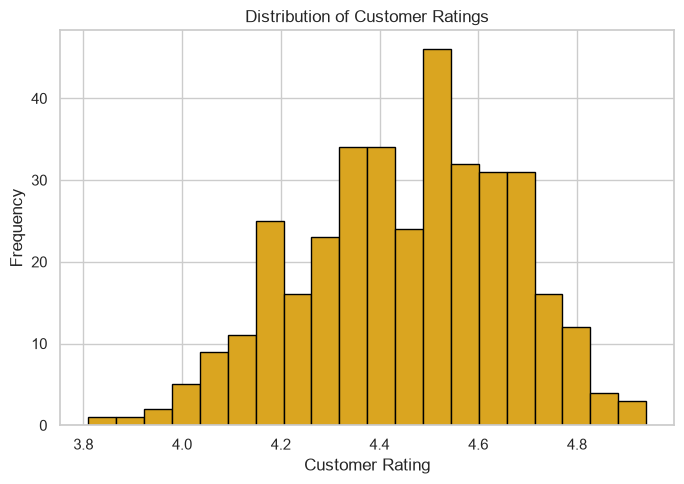

In [22]:
plt.figure(figsize=(7,5))
plt.hist(df['Customer_Rating'], bins=20, color='goldenrod', edgecolor='black')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Customer Rating')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


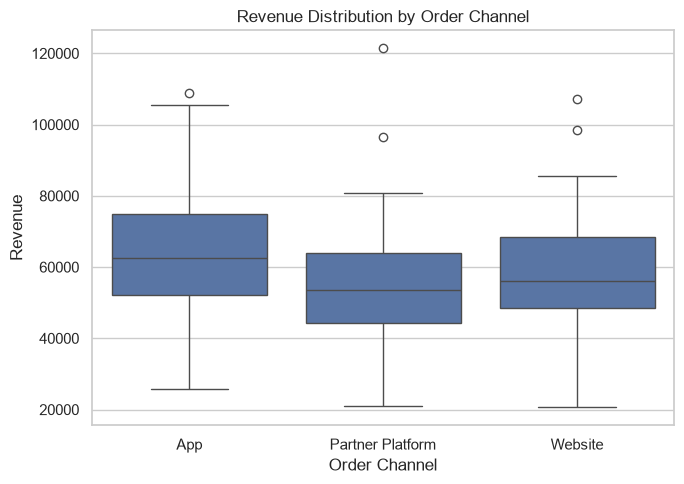

In [23]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Order_Channel', y='Revenue', data=df)
plt.title('Revenue Distribution by Order Channel')
plt.xlabel('Order Channel')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

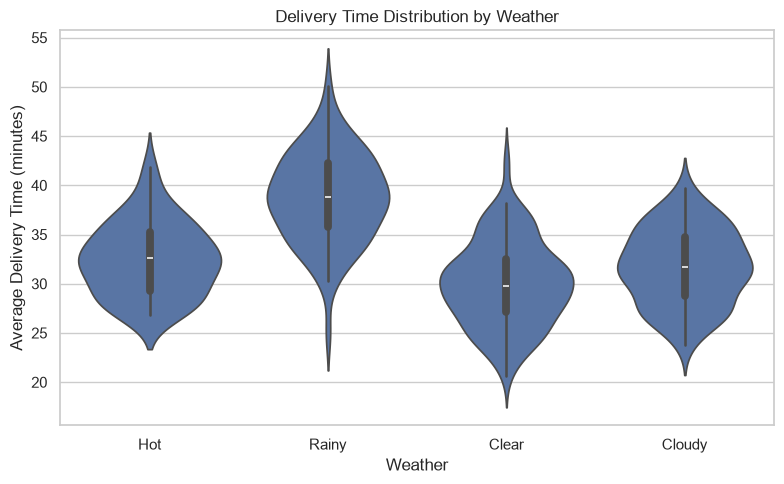

In [24]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Weather', y='Avg_Delivery_Minutes', data=df)
plt.title('Delivery Time Distribution by Weather')
plt.xlabel('Weather')
plt.ylabel('Average Delivery Time (minutes)')
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_36136\1907177524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='City', data=df, order=df['City'].value_counts().index, palette='viridis')


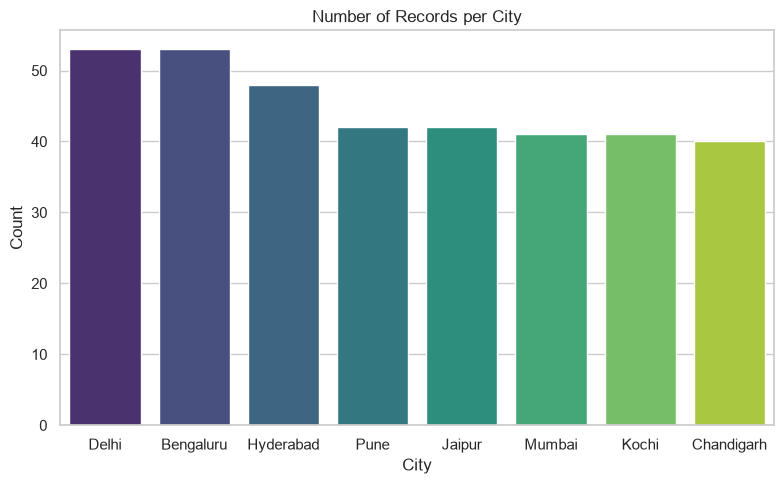

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='City', data=df, order=df['City'].value_counts().index, palette='viridis')
plt.title('Number of Records per City')
plt.xlabel('City')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

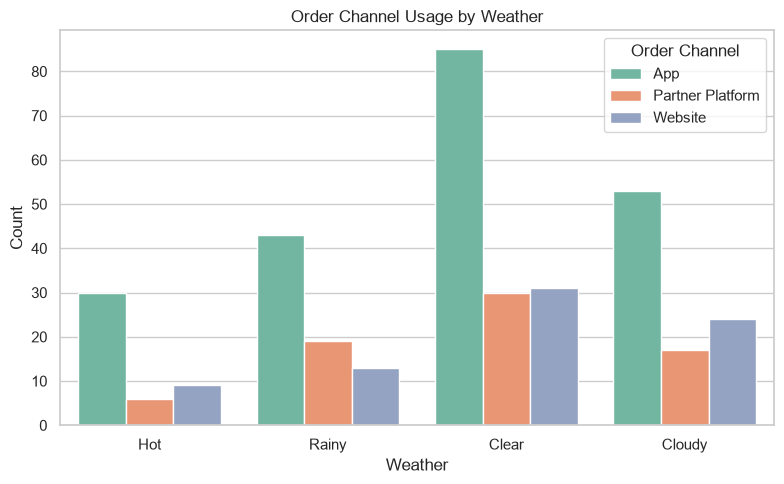

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='Weather', hue='Order_Channel', data=df, palette='Set2')
plt.title('Order Channel Usage by Weather')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.legend(title='Order Channel')
plt.tight_layout()
plt.show()

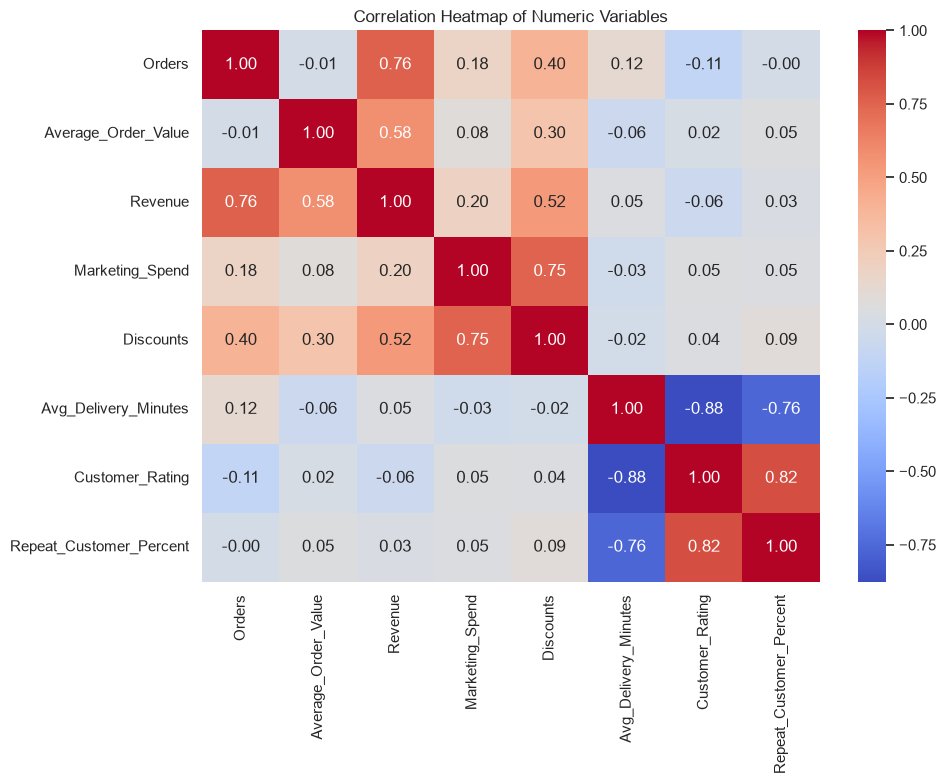

In [27]:
num_cols = ['Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts',
            'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

In [28]:
print("Top city by revenue:", city_revenue.idxmax())
print("Top cuisine by orders:", cuisine_orders.idxmax())
print("Correlation - Marketing Spend vs Revenue:", round(df['Marketing_Spend'].corr(df['Revenue']), 3))
print("Correlation - Delivery Time vs Customer Rating:", round(df['Avg_Delivery_Minutes'].corr(df['Customer_Rating']), 3))
print("Correlation - Orders vs Revenue:", round(df['Orders'].corr(df['Revenue']), 3))

Top city by revenue: Bengaluru
Top cuisine by orders: South Indian
Correlation - Marketing Spend vs Revenue: 0.198
Correlation - Delivery Time vs Customer Rating: -0.876
Correlation - Orders vs Revenue: 0.76
